<a href="https://colab.research.google.com/github/cavalcantiju/visaocomp-3.4-cacador/blob/main/semana3_cacador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



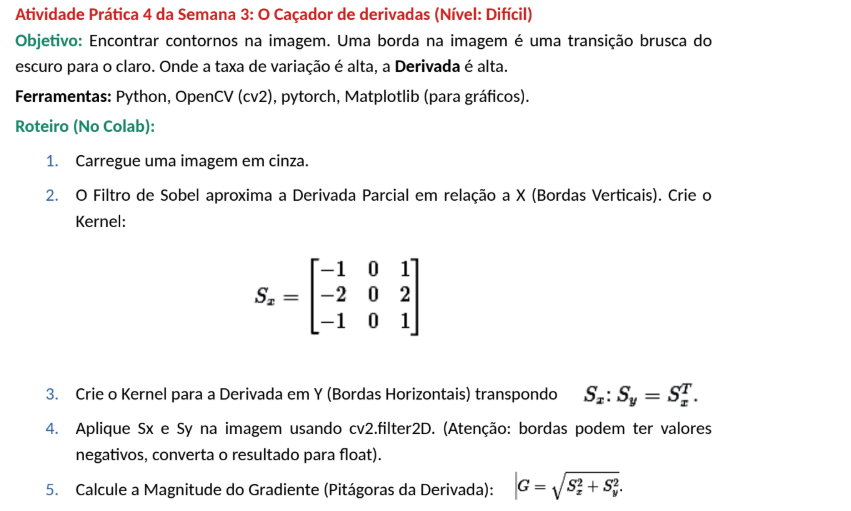

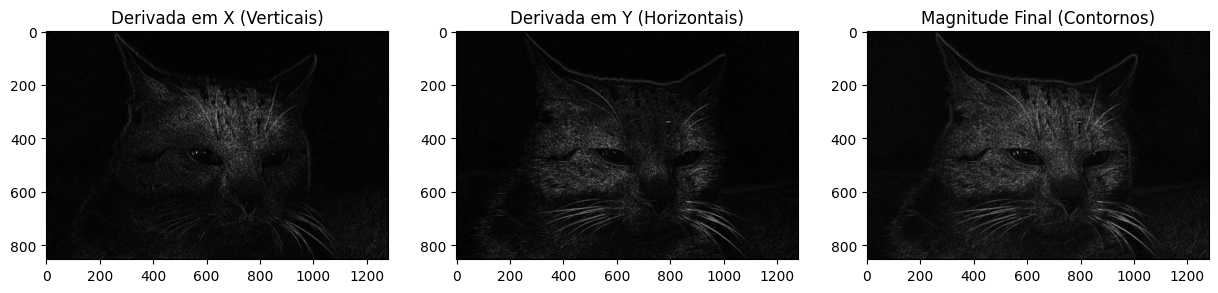

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar imagem em cinza
img = cv2.imread('gatocinza.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Erro ao carregar a imagem!")
else:
    # 2. Kernel Sobel X (Bordas Verticais)
    Sx = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]])

    # 3. Kernel Sobel Y (Bordas Horizontais) - Transposta de Sx
    Sy = Sx.T

    # 4. Aplicar Convolução (usando float64 para não perder valores negativos)
    # Bordas podem ir do branco pro preto (negativo) ou vice-versa (positivo)
    grad_x = cv2.filter2D(img.astype(np.float64), -1, Sx)
    grad_y = cv2.filter2D(img.astype(np.float64), -1, Sy)

    # 5. Magnitude do Gradiente (Pitágoras da Derivada)
    # G = sqrt(Gx^2 + Gy^2)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)

    # Converter de volta para uint8 para exibir
    magnitude = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Visualização
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(np.abs(grad_x), cmap='gray'); plt.title("Derivada em X (Verticais)")
    plt.subplot(1, 3, 2); plt.imshow(np.abs(grad_y), cmap='gray'); plt.title("Derivada em Y (Horizontais)")
    plt.subplot(1, 3, 3); plt.imshow(magnitude, cmap='gray'); plt.title("Magnitude Final (Contornos)")
    plt.show()

## Detecção de bordas com Sobel

A ideia é identificar bordas na imagem, ou seja, regiões onde a intensidade muda rapidamente (transição de claro para escuro).

Primeiro, a imagem é carregada em escala de cinza, porque a detecção de bordas depende apenas da intensidade dos pixels, não das cores.

Em seguida, definimos o kernel Sobel X:
Sx = [[-1, 0, 1],
      [-2, 0, 2],
      [-1, 0, 1]]
Esse kernel detecta variações na horizontal, destacando bordas verticais.

O kernel Sobel Y é obtido pela transposta do Sx:
Sy = Sx.T
Ele detecta variações na vertical, ou seja, bordas horizontais.

Depois aplicamos a convolução com esses kernels usando filter2D. A imagem é convertida para float64 porque os valores do gradiente podem ser negativos, dependendo da direção da variação de intensidade.

Assim obtemos:
grad_x → intensidade das bordas verticais
grad_y → intensidade das bordas horizontais

Para combinar essas informações, calculamos a magnitude do gradiente:
magnitude = sqrt(grad_x² + grad_y²)

Isso corresponde à combinação das variações nas duas direções, resultando na força total da borda em cada pixel.

Por fim, normalizamos os valores para o intervalo de 0 a 255 para permitir a visualização como imagem.

O resultado mostra:
grad_x com bordas verticais
grad_y com bordas horizontais
magnitude com todos os contornos combinados

Em resumo, o operador Sobel calcula a derivada da imagem. Onde a derivada é alta, há uma mudança brusca de intensidade, caracterizando uma borda.